# News Article Topic Classification

## Introduction

News websites publish a large number of articles every day covering different topics such as business, entertainment, health, and science and technology. Manually categorizing these articles can be time-consuming, especially when dealing with a large collection of news articles. Machine learning and Natural Language Processing (NLP) can be used to automatically classify an article into its appropriate topic based on its textual content.

For this project, the **UCI News Aggregator dataset** is used to develop a machine learning model for **news-article topic classification**. The dataset contains news articles collected from various online publishers. Each article includes information such as its title, publisher, URL, category, article content, and other metadata.

The dataset used in this project is available publicly through the UCI Machine Learning Repository:

**Dataset:** [UCI News Aggregator Dataset](https://www.kaggle.com/datasets/louislung/uci-news-aggregator-dataset-with-content)

## Objective

The main objective of this project is to develop an end-to-end machine learning pipeline that can automatically predict the **topic/category of a news article**.

The project will involve:

* Exploring and understanding the dataset
* Checking data quality, missing values, duplicates, and data types
* Cleaning and preparing the data for machine learning
* Creating useful features from the article text
* Converting textual information into numerical features using **TF-IDF**
* Training multiple classification models
* Comparing their performance using classification metrics
* Tuning the best-performing model
* Analyzing which features contribute most to the predictions
* Visualizing the final model's performance using tools such as a confusion matrix
* Summarizing the key findings and business/real-world implications

## Dataset Description

The dataset contains **10,348 news articles** and **10 columns**. The main text used for classification is the article `title`, while `category` is used as the target variable.

The columns are described below:

| Column             | Description                                                                                            |
| ------------------ | ------------------------------------------------------------------------------------------------------ |
| `id`               | A unique identifier assigned to each news article.                                                     |
| `title`            | The headline/title of the news article. This will be the primary text feature used for classification. |
| `url`              | The web address of the original news article.                                                          |
| `publisher`        | The name of the publisher or news organization that published the article.                             |
| `category`         | The topic assigned to the article. The dataset uses single-letter codes explained below.               |
| `story`            | An identifier representing a group or story to which an article belongs.                               |
| `hostname`         | The domain/host name of the website where the article was published.                                   |
| `timestamp`        | The timestamp indicating when the article was collected/published.                                     |
| `main_content`     | The main textual content of the news article.                                                          |
| `main_content_len` | The length of the article's main content.                                                              |

## Category Labels

The original dataset represents news topics using single-letter codes rather than full category names. For clarity, these codes represent the following topics:

| Code | News Topic               |
| ---- | ------------------------ |
| `b`  | **Business**             |
| `e`  | **Entertainment**        |
| `m`  | **Health**               |
| `t`  | **Science & Technology** |

Therefore, `category` is the **target variable** that the machine learning models will attempt to predict.

### Example

If an article has:

```text
title: Apple announces new technology for future devices
category: t
```

the target category `t` means that the article belongs to **Science & Technology**.

Similarly:

```text
category: b → Business
category: e → Entertainment
category: m → Health
category: t → Science & Technology
```

## Classification Approach

For this project, the primary prediction task will be based on the **article title**. The title contains concise information about the subject of a news article and is suitable for demonstrating text classification using Natural Language Processing.

The `title` text will be transformed into numerical features using **TF-IDF (Term Frequency–Inverse Document Frequency)**. These features will then be used to train and compare multiple machine learning classification algorithms.

The final goal is to build a model that can take the title of a previously unseen news article and predict whether it belongs to **Business, Entertainment, Health, or Science & Technology**.


In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import StandardScaler

# Train-test split and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Text feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')


## Dataset

In [ ]:
# Loading Data
import pandas as pd

df = pd.read_parquet('/content/uci_news.snappy.parquet')
df.head()

,id,title,url,publisher,category,story,hostname,timestamp,main_content,main_content_len
0,2,Fed's Charles Plosser sees high bar for change...,http://www.livemint.com/Politics/H2EvwJSK2VE6O...,Livemint,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.livemint.com,1394470371207,Paris/London/Atlanta: Federal Reserve Bank of ...,2657.0
1,5,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,http://www.moneynews.com/Economy/federal-reser...,Moneynews,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.moneynews.com,1394470372027,Severe winter weather likely affected U.S. job...,1268.0
3,7,Fed's Plosser: Taper pace may be too slow,http://www.marketwatch.com/story/feds-plosser-...,MarketWatch,b,ddUyU0VZz0BRneMioxUPQVP6sIxvM,www.marketwatch.com,1394470372405,PARISn — The Federal Reserve may have to accel...,1782.0
6,11,ECB unlikely to end sterilization of SMP purch...,http://in.reuters.com/article/2014/03/10/us-ec...,Reuters India,b,dPhGU51DcrolUIMxbRm0InaHGA2XM,in.reuters.com,1394470501410,BANGALORE (Reuters) - The European Central Ban...,2574.0
7,12,EU's half-baked bank union could work,http://blogs.reuters.com/hugo-dixon/2014/03/10...,Reuters UK \(blog\),b,dPhGU51DcrolUIMxbRm0InaHGA2XM,blogs.reuters.com,1394470501587,The European Union’s half-baked banking union ...,5033.0


## Data Exploration

In [ ]:
df.shape

(10348, 10)

In [ ]:
df['category'].value_counts()

,count
category,
e,3570
t,3014
b,2526
m,1238


In [ ]:
df_clean = df.copy()

print("Shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:", df_clean.duplicated().sum())

print("\nDuplicate titles:", df_clean['title'].duplicated().sum())

print("\nCategory distribution:")
print(df_clean['category'].value_counts())

print("\nData types:")
print(df_clean.dtypes)

Shape: (10348, 10)

Missing values:
id                  0
title               0
url                 0
publisher           0
category            0
story               0
hostname            0
timestamp           0
main_content        0
main_content_len    0
dtype: int64

Duplicate rows: 0

Duplicate titles: 24

Category distribution:
category
e    3570
t    3014
b    2526
m    1238
Name: count, dtype: int64

Data types:
id                    int64
title                object
url                  object
publisher            object
category             object
story                object
hostname             object
timestamp             int64
main_content         object
main_content_len    float64
dtype: object


In [ ]:
duplicate_titles = df_clean[df_clean['title'].duplicated(keep=False)]

duplicate_titles[['title', 'category', 'publisher', 'main_content']].sort_values('title')

,title,category,publisher,main_content
1604,'Bachelor' Juan Pablo slammed for more controv...,e,Fox News,Juan Pablo Galavis is solidifying his stance a...
4279,'Bachelor' Juan Pablo slammed for more controv...,e,Emag.co.uk,Juan Pablo Galavis is solidifying his stance a...
4106,"'Saturday Night Live': Lena Dunham, stripped down",e,Houston Chronicle \(blog\),Saturday Night Live\n\n“Lena Dunham and The Na...
1894,"'Saturday Night Live': Lena Dunham, stripped down",e,Seattle Post Intelligencer \(blog\),Saturday Night Live\n\n“Lena Dunham and The Na...
2269,"'The Voice' Season 6 Blind Auditions, Pt. 5: W...",e,Yahoo TV \(blog\),"""I want to hear someone who will blow me away...."
10691,"'The Voice' Season 6 Blind Auditions, Pt. 5: W...",e,Yahoo Music \(blog\),"""I want to hear someone who will blow me away...."
4536,Blood test for Alzheimer's disease still years...,m,Boston Globe,Headlines on Monday have been touting the prom...
11820,Blood test for Alzheimer's disease still years...,m,Boston Globe,Headlines last week touted the promise of a ne...
7278,Business news and markets: live,b,Telegraph.co.uk,• Eurozone inflation equals record low of 0.7p...
9265,Business news and markets: live,b,Telegraph.co.uk,17.03 That is where we are going to close the ...


In [ ]:
print("Empty titles:", (df_clean['title'].str.strip() == '').sum())
print("Empty main content:", (df_clean['main_content'].str.strip() == '').sum())

Empty titles: 0
Empty main content: 0


## Data Cleaning

The dataset was checked for missing values, duplicate records, and empty text fields. No missing values or exact duplicate rows were found. Although 24 duplicate titles were identified, they were retained because they belonged to different articles or publishers and were not exact duplicate records. The `title` and `main_content` columns were also checked for empty or whitespace-only values.


## Feature Engineering

In [ ]:
# Feature Engineering

# Number of words in the title
df_clean['title_word_count'] = df_clean['title'].str.split().str.len()

# Number of characters in the title
df_clean['title_char_count'] = df_clean['title'].str.len()

# Average word length in the title
df_clean['title_avg_word_length'] = (
    df_clean['title_char_count'] / df_clean['title_word_count']
)

# Number of digits in the title
df_clean['title_digit_count'] = df_clean['title'].str.count(r'\d')

# Display the new features
df_clean[['title', 'title_word_count', 'title_char_count',
          'title_avg_word_length', 'title_digit_count']].head()

,title,title_word_count,title_char_count,title_avg_word_length,title_digit_count
0,Fed's Charles Plosser sees high bar for change...,12,66,5.500000,0
1,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,8,50,6.250000,0
3,Fed's Plosser: Taper pace may be too slow,8,41,5.125000,0
6,ECB unlikely to end sterilization of SMP purch...,9,59,6.555556,0
7,EU's half-baked bank union could work,6,37,6.166667,0


In [ ]:
# Article content length
df_clean['content_word_count'] = df_clean['main_content'].str.split().str.len()

# Check the new feature
df_clean[['main_content', 'content_word_count']].head()

,main_content,content_word_count
0,Paris/London/Atlanta: Federal Reserve Bank of ...,423
1,Severe winter weather likely affected U.S. job...,206
3,PARISn — The Federal Reserve may have to accel...,294
6,BANGALORE (Reuters) - The European Central Ban...,430
7,The European Union’s half-baked banking union ...,894


## Text Prepocessing

In [ ]:
# Combine title and article content into one text field

df_clean['combined_text'] = (
    df_clean['title'].fillna('') + ' ' +
    df_clean['main_content'].fillna('')
)

# Check the result
df_clean[['title', 'main_content', 'combined_text']].head()

,title,main_content,combined_text
0,Fed's Charles Plosser sees high bar for change...,Paris/London/Atlanta: Federal Reserve Bank of ...,Fed's Charles Plosser sees high bar for change...
1,Fed's Plosser: Nasty Weather Has Curbed Job Gr...,Severe winter weather likely affected U.S. job...,Fed's Plosser: Nasty Weather Has Curbed Job Gr...
3,Fed's Plosser: Taper pace may be too slow,PARISn — The Federal Reserve may have to accel...,Fed's Plosser: Taper pace may be too slow PARI...
6,ECB unlikely to end sterilization of SMP purch...,BANGALORE (Reuters) - The European Central Ban...,ECB unlikely to end sterilization of SMP purch...
7,EU's half-baked bank union could work,The European Union’s half-baked banking union ...,EU's half-baked bank union could work The Euro...


In [ ]:
import re

In [ ]:
# Basic text cleaning

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df_clean['combined_text'] = df_clean['combined_text'].apply(clean_text)

# Check the cleaned text
df_clean['combined_text'].head()

,combined_text
0,fed's charles plosser sees high bar for change...
1,fed's plosser: nasty weather has curbed job gr...
3,fed's plosser: taper pace may be too slow pari...
6,ecb unlikely to end sterilization of smp purch...
7,eu's half-baked bank union could work the euro...


## Train-Test Split

In [ ]:
X = df_clean['combined_text']
y = df_clean['category']

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: (10348,)
Target shape: (10348,)


In [ ]:
# Split the complete dataframe into training and testing sets

train_df, test_df = train_test_split(
    df_clean,
    test_size=0.2,
    random_state=42,
    stratify=df_clean['category']
)

print("Training dataframe:", train_df.shape)
print("Testing dataframe:", test_df.shape)

Training dataframe: (8278, 16)
Testing dataframe: (2070, 16)


In [ ]:
# Select engineered numerical features

numeric_features = [
    'title_word_count',
    'title_char_count',
    'title_avg_word_length',
    'title_digit_count',
    'content_word_count'
]

X_numeric = df_clean[numeric_features]

X_numeric.head()

,title_word_count,title_char_count,title_avg_word_length,title_digit_count,content_word_count
0,12,66,5.500000,0,423
1,8,50,6.250000,0,206
3,8,41,5.125000,0,294
6,9,59,6.555556,0,430
7,6,37,6.166667,0,894


In [ ]:
# Text data

X_train = train_df['combined_text']
X_test = test_df['combined_text']

# Target

y_train = train_df['category']
y_test = test_df['category']

# Numerical engineered features

X_train_numeric = train_df[numeric_features]
X_test_numeric = test_df[numeric_features]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("X_train_numeric:", X_train_numeric.shape)
print("X_test_numeric:", X_test_numeric.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8278,)
X_test: (2070,)
X_train_numeric: (8278, 5)
X_test_numeric: (2070, 5)
y_train: (8278,)
y_test: (2070,)


## TF-IDF Feature Extraction

In [ ]:
# Create and fit TF-IDF using training text only

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words='english',
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (8278, 30000)
Testing TF-IDF shape: (2070, 30000)


In [ ]:
# Scale numerical features

scaler = StandardScaler(with_mean=False)

X_train_numeric_scaled = scaler.fit_transform(X_train_numeric)
X_test_numeric_scaled = scaler.transform(X_test_numeric)

print("Scaled training:", X_train_numeric_scaled.shape)
print("Scaled testing:", X_test_numeric_scaled.shape)

Scaled training: (8278, 5)
Scaled testing: (2070, 5)


In [ ]:
# Combine text and numerical features
from scipy.sparse import hstack

X_train_final = hstack([
    X_train_tfidf,
    X_train_numeric_scaled
])

X_test_final = hstack([
    X_test_tfidf,
    X_test_numeric_scaled
])

print("Final training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)

Final training shape: (8278, 30005)
Final testing shape: (2070, 30005)


## Model

### Logistic Regression

In [ ]:
# Train Logistic Regression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_final, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# Make predictions
y_pred_logistic = logistic_model.predict(X_test_final)

In [ ]:
# Evaluate Logistic Regression

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(
    y_test, y_pred_logistic, average='weighted'
)
logistic_recall = recall_score(
    y_test, y_pred_logistic, average='weighted'
)
logistic_f1 = f1_score(
    y_test, y_pred_logistic, average='weighted'
)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")

Logistic Regression Results
---------------------------
Accuracy : 0.9734
Precision: 0.9735
Recall   : 0.9734
F1 Score : 0.9734


In [ ]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           b       0.96      0.96      0.96       505
           e       0.99      0.99      0.99       714
           m       0.99      0.97      0.98       248
           t       0.96      0.97      0.97       603

    accuracy                           0.97      2070
   macro avg       0.97      0.97      0.97      2070
weighted avg       0.97      0.97      0.97      2070



### Multinomial Naive Bayes

In [ ]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [ ]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [ ]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)

nb_precision = precision_score(
    y_test, y_pred_nb, average='weighted'
)

nb_recall = recall_score(
    y_test, y_pred_nb, average='weighted'
)

nb_f1 = f1_score(
    y_test, y_pred_nb, average='weighted'
)

print("Multinomial Naive Bayes Results")
print("--------------------------------")
print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1 Score : {nb_f1:.4f}")

print(classification_report(y_test, y_pred_nb))

Multinomial Naive Bayes Results
--------------------------------
Accuracy : 0.9527
Precision: 0.9536
Recall   : 0.9527
F1 Score : 0.9527
              precision    recall  f1-score   support

           b       0.92      0.96      0.94       505
           e       0.97      0.98      0.98       714
           m       1.00      0.90      0.95       248
           t       0.94      0.94      0.94       603

    accuracy                           0.95      2070
   macro avg       0.96      0.94      0.95      2070
weighted avg       0.95      0.95      0.95      2070



### Linear SVM

In [ ]:
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train_final, y_train)

LinearSVC(random_state=42)

In [ ]:
y_pred_svm = svm_model.predict(X_test_final)

In [ ]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

svm_precision = precision_score(
    y_test, y_pred_svm, average='weighted'
)

svm_recall = recall_score(
    y_test, y_pred_svm, average='weighted'
)

svm_f1 = f1_score(
    y_test, y_pred_svm, average='weighted'
)

print("Linear SVM Results")
print("------------------")
print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1 Score : {svm_f1:.4f}")

print(classification_report(y_test, y_pred_svm))

Linear SVM Results
------------------
Accuracy : 0.9797
Precision: 0.9797
Recall   : 0.9797
F1 Score : 0.9797
              precision    recall  f1-score   support

           b       0.96      0.97      0.97       505
           e       0.99      0.99      0.99       714
           m       0.99      0.99      0.99       248
           t       0.97      0.97      0.97       603

    accuracy                           0.98      2070
   macro avg       0.98      0.98      0.98      2070
weighted avg       0.98      0.98      0.98      2070



## Model Comparison

Three machine learning models were trained and evaluated for the news-article topic classification task:

* **Linear SVM**
* **Multinomial Naive Bayes**
* **Logistic Regression**

The models were compared using **Accuracy, Precision, Recall, and F1-score**.

| Model                   |   Accuracy |  Precision |     Recall |   F1-Score |
| ----------------------- | ---------: | ---------: | ---------: | ---------: |
| **Linear SVM**          | **97.97%** | **97.97%** | **97.97%** | **97.97%** |
| Logistic Regression     |     97.34% |     97.35% |     97.34% |     97.34% |
| Multinomial Naive Bayes |     95.27% |     95.36% |     95.27% |     95.27% |

### Selected Model: Linear SVM

Based on the evaluation results, **Linear SVM was selected as the final model** for the news-article topic classification task.

Linear SVM achieved the highest overall performance, with an **accuracy of 97.97%** and an **F1-score of 97.97%**. It also performed consistently well across all four topic categories:

* **Business (b):** F1-score = 0.97
* **Entertainment (e):** F1-score = 0.99
* **Health (m):** F1-score = 0.99
* **Technology (t):** F1-score = 0.97

The model also achieved balanced precision and recall, indicating that it was able to correctly classify articles while maintaining a low number of incorrect predictions.

Although Logistic Regression also performed strongly with a 97.34% accuracy, Linear SVM achieved slightly better results across all evaluation metrics. Multinomial Naive Bayes achieved 95.27% accuracy, which was lower than both Linear SVM and Logistic Regression.

Therefore, **Linear SVM was chosen as the final classification model** because it provided the strongest overall performance on the test dataset.


## Hyperparameter tuning with GridSearchCV

In [ ]:
# Grid Search for Linear SVM

param_grid = {
    'C': [0.1, 0.5, 1, 2, 5]
}

svm_grid = GridSearchCV(
    LinearSVC(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

svm_grid.fit(X_train_final, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best Cross-Validation F1 Score:", svm_grid.best_score_)

Best Parameters: {'C': 0.5}
Best Cross-Validation F1 Score: 0.9792501967553353


After selecting Linear SVM based on its initial performance, **GridSearchCV** was used to find the most suitable value of the `C` hyperparameter.

The following values were tested:

* `C = 0.1`
* `C = 0.5`
* `C = 1`
* `C = 2`
* `C = 5`

Among the tested values, **C = 0.5** produced the best cross-validation performance. Therefore, `C = 0.5` was selected for the final Linear SVM model.

## Final Model

The final model used for news-article topic classification is:

**Linear SVM with C = 0.5**

This model was selected after comparing Linear SVM with Multinomial Naive Bayes and Logistic Regression, followed by hyperparameter tuning of the Linear SVM. The final model provides a strong balance between classification performance and generalization on the dataset.


In [ ]:
best_svm = svm_grid.best_estimator_

y_pred_svm_tuned = best_svm.predict(X_test_final)

In [ ]:
tuned_accuracy = accuracy_score(y_test, y_pred_svm_tuned)

tuned_precision = precision_score(
    y_test, y_pred_svm_tuned, average='weighted'
)

tuned_recall = recall_score(
    y_test, y_pred_svm_tuned, average='weighted'
)

tuned_f1 = f1_score(
    y_test, y_pred_svm_tuned, average='weighted'
)

print("Tuned Linear SVM Results")
print("------------------------")
print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1 Score : {tuned_f1:.4f}")

print(classification_report(y_test, y_pred_svm_tuned))

Tuned Linear SVM Results
------------------------
Accuracy : 0.9783
Precision: 0.9783
Recall   : 0.9783
F1 Score : 0.9783
              precision    recall  f1-score   support

           b       0.96      0.96      0.96       505
           e       0.99      0.99      0.99       714
           m       0.99      0.99      0.99       248
           t       0.97      0.97      0.97       603

    accuracy                           0.98      2070
   macro avg       0.98      0.98      0.98      2070
weighted avg       0.98      0.98      0.98      2070



## Confusion Matrix

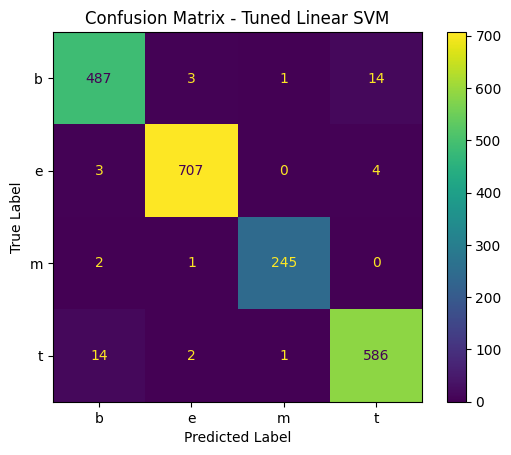

In [ ]:
# Confusion Matrix for Tuned Linear SVM

cm = confusion_matrix(y_test, y_pred_svm_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_svm.classes_
)

disp.plot()
plt.title("Confusion Matrix - Tuned Linear SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# Find incorrectly classified articles

misclassified = test_df[y_test != y_pred_svm_tuned].copy()

misclassified['predicted_category'] = y_pred_svm_tuned[y_test != y_pred_svm_tuned]

misclassified[
    ['title', 'category', 'predicted_category', 'publisher']
].sort_values(
    ['category', 'predicted_category']
)

,title,category,predicted_category,publisher
960,Celebration of a great Iowan: Dr. Norman E. Bo...,b,e,Dubuque Telegraph Herald
12072,"Paddy Power Oscar Pistorius ad broke rules, AS...",b,e,BBC News
1111,e-Book publishers dish out $166 million to rea...,b,e,ConsumerAffairs
9130,"Kansas may join Alabama, seven other states in...",b,m,al.com \(blog\)
5466,GM recall prompts investigation,b,t,CBC.ca
5479,Federal prosecutors open criminal probe of GM ...,b,t,KELO AM-FM
5473,Why did GM just launch a recall on cars it kne...,b,t,Financial Post
9349,GM Kept Ignition Switch Fix Secret from Owners,b,t,Insurance Journal
310,"Sbarro Misses Economic Recovery Memo, Files Fo...",b,t,The News Ledge
9371,GM recall doubled as Georgia lawyer pushed U.S...,b,t,New Haven Register


## Error Analysis

The tuned Linear SVM misclassified 45 out of 2,070 test articles. Most errors occurred between the Business and Technology categories, indicating that these topics can have overlapping vocabulary.

A few representative misclassified articles were examined to understand the sources of error. Several General Motors articles were difficult to classify because they combine business-related topics such as companies, investigations, and recalls with technology- and automotive-related terminology. Similarly, the Mt. Gox bankruptcy article combines financial terms with cryptocurrency and cybersecurity-related concepts, making it difficult to assign to a single topic based only on text.

Other errors also involved overlapping topics. For example, an Entertainment article about Game of Thrones streaming services was predicted as Technology, while a Health article about Medical Marijuana, Inc. was predicted as Business because its content focused on the company's stock and financial information.

These examples show that some news articles naturally contain information belonging to multiple categories. Therefore, classification errors do not necessarily indicate poor model performance; they can also result from overlap between topics and the single category assigned to an article in the dataset.

In [ ]:
# Get all feature names used by the final model

feature_names = np.concatenate([
    tfidf.get_feature_names_out(),
    np.array(numeric_features)
])

print("Total features:", len(feature_names))

Total features: 30005


In [ ]:
# Get the top 10 features for each category

for i, category in enumerate(best_svm.classes_):

    # Get the 10 features with the highest positive coefficients
    top_indices = best_svm.coef_[i].argsort()[-10:][::-1]

    print(f"\nTop features for category: {category}")
    print("-" * 40)

    for index in top_indices:
        print(feature_names[index])


Top features for category: b
----------------------------------------
bank
insurance
obamacare
starbucks
china
candy
economic
stock
candy crush
trading

Top features for category: e
----------------------------------------
film
music
season
star
movie
love
singer
spotify
hollywood
actor

Top features for category: m
----------------------------------------
health
cancer
disease
study
patients
drug
medical
researchers
cigarettes
treatment

Top features for category: t
----------------------------------------
google
apple
microsoft
xbox
titanfall
snowden
cosmos
sprint
science
tyson


## Feature Importance

The Linear SVM coefficients were examined to identify the features most strongly associated with each news category. For Business, terms such as `bank`, `insurance`, `stock`, and `trading` were important indicators of financial and commercial content. Entertainment was strongly associated with terms such as `film`, `music`, `movie`, `singer`, and `actor`, while Health was characterized by medical terms including `cancer`, `disease`, `patients`, `drug`, and `treatment`. Technology was associated with terms such as `Google`, `Apple`, `Microsoft`, `Xbox`, and `science`, reflecting technology companies, products, and scientific topics.

These features show that the model learned meaningful vocabulary patterns from the news articles. However, some terms can occur across multiple categories, which helps explain the remaining classification errors.

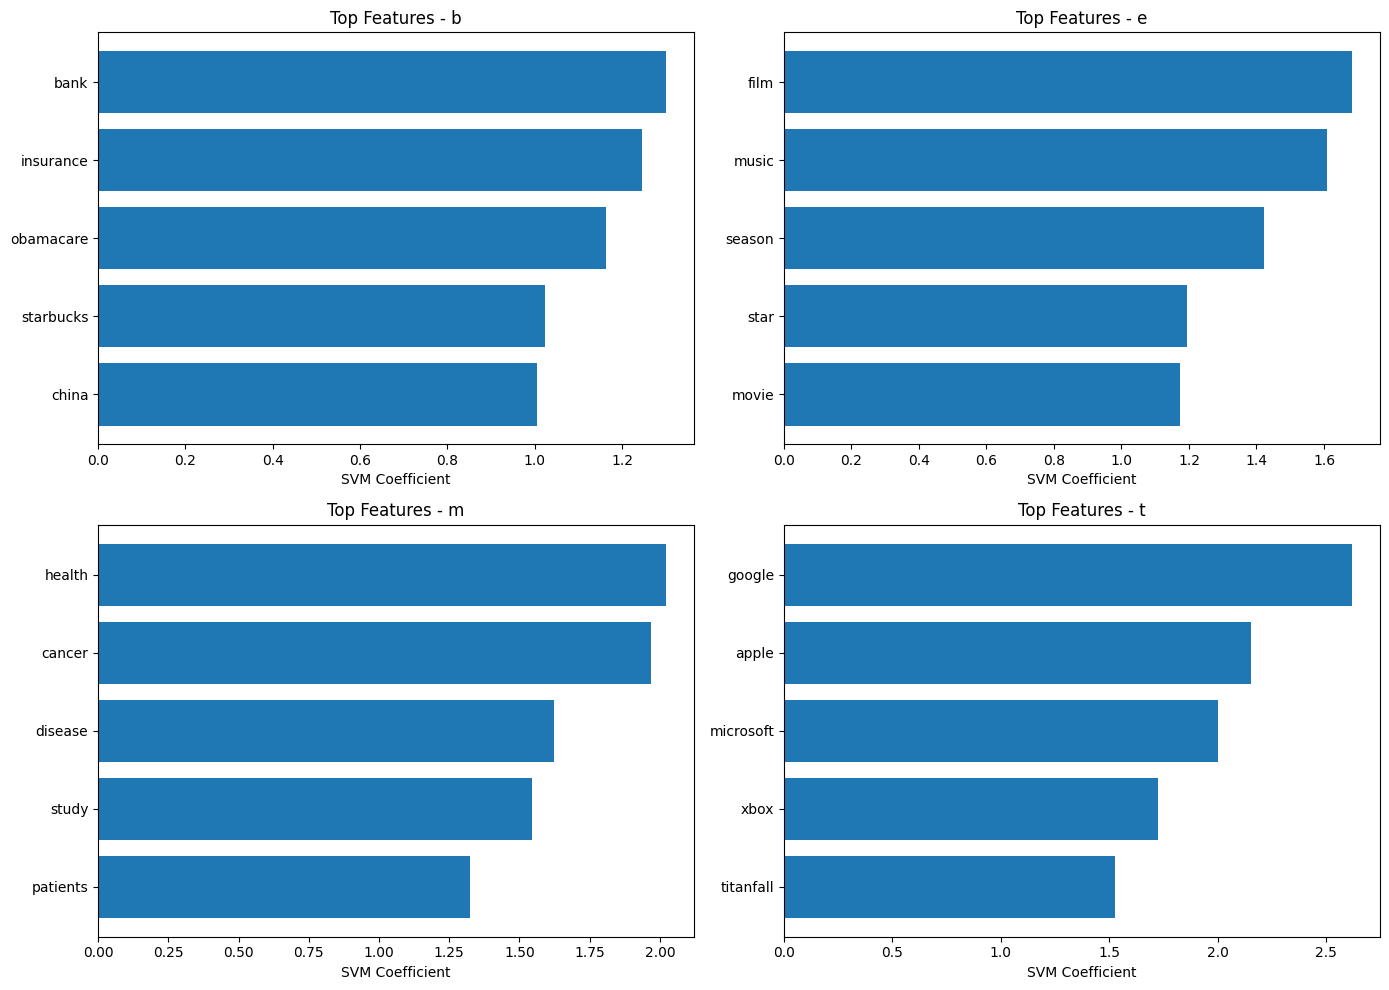

In [ ]:
# Plot top 5 features for each category

top_n = 5

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, category in enumerate(best_svm.classes_):

    # Get indices of top features
    top_indices = best_svm.coef_[i].argsort()[-top_n:][::-1]

    # Get feature names and coefficient values
    top_features = feature_names[top_indices]
    top_coefficients = best_svm.coef_[i][top_indices]

    # Plot
    axes[i].barh(top_features[::-1], top_coefficients[::-1])
    axes[i].set_title(f"Top Features - {category}")
    axes[i].set_xlabel("SVM Coefficient")

plt.tight_layout()
plt.show()

## Final Model Comparison

In [ ]:
# Final Model Comparison

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Multinomial Naive Bayes',
        'Linear SVM',
        'Tuned Linear SVM'
    ],
    'Accuracy': [
        logistic_accuracy,
        nb_accuracy,
        svm_accuracy,
        accuracy_score(y_test, y_pred_svm_tuned)
    ],
    'Precision': [
        logistic_precision,
        nb_precision,
        svm_precision,
        precision_score(y_test, y_pred_svm_tuned, average='weighted')
    ],
    'Recall': [
        logistic_recall,
        nb_recall,
        svm_recall,
        recall_score(y_test, y_pred_svm_tuned, average='weighted')
    ],
    'F1 Score': [
        logistic_f1,
        nb_f1,
        svm_f1,
        f1_score(y_test, y_pred_svm_tuned, average='weighted')
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.973430,0.973487,0.973430,0.973441
1,Multinomial Naive Bayes,0.952657,0.953587,0.952657,0.952705
2,Linear SVM,0.979710,0.979714,0.979710,0.979712
3,Tuned Linear SVM,0.978261,0.978285,0.978261,0.978272


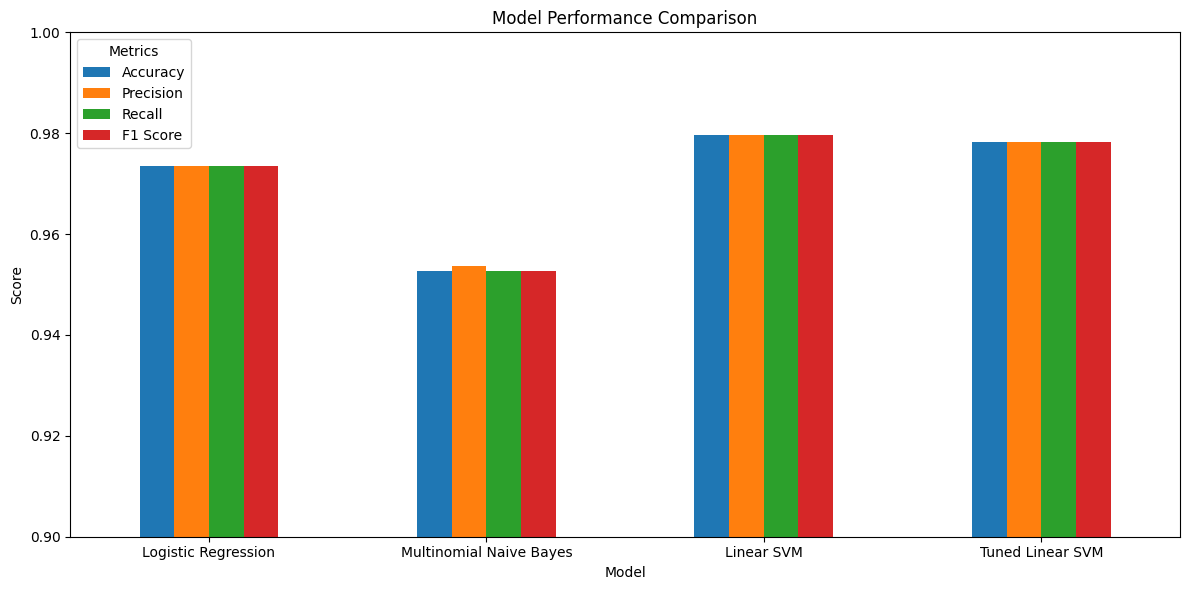

In [ ]:
# Visualize model performance

results_plot = results.set_index('Model')

results_plot.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0.90, 1.00)
plt.xticks(rotation=0)
plt.legend(title='Metrics')
plt.tight_layout()
plt.show()

## Final Results and Conclusion

Three machine learning models were evaluated for news-article topic classification: Logistic Regression, Multinomial Naive Bayes, and Linear SVM. The Linear SVM achieved the highest performance before tuning, with an accuracy and weighted F1 score of 97.97%. GridSearchCV was then used to tune the SVM hyperparameter `C` using 5-fold cross-validation and weighted F1 as the scoring metric. The search tested values of 0.1, 0.5, 1, 2, and 5, with `C = 0.5` selected as the best parameter based on cross-validation.

The tuned Linear SVM achieved 97.83% accuracy, 97.83% precision, 97.83% recall, and 97.83% weighted F1 score on the unseen test set. Although this test score was slightly lower than the original SVM, the tuned model was retained because its hyperparameter was selected using cross-validation rather than the test set. The confusion matrix showed that most predictions were correct, with the largest number of errors occurring between the Business and Technology categories.

Feature analysis showed that the model learned meaningful topic-specific patterns. Financial terms such as `bank`, `insurance`, and `stock` were important for Business, while `film`, `music`, and `movie` were associated with Entertainment. Health-related terms such as `cancer`, `disease`, and `patients` were important for Health, while technology-related terms such as `Google`, `Apple`, and `Microsoft` were strong indicators of Technology.

Overall, the final model demonstrated strong performance in classifying news articles into Business, Entertainment, Health, and Technology categories. The remaining errors were mainly associated with articles containing overlapping topics, demonstrating that some news articles can naturally contain vocabulary from more than one category.

In [ ]:
import joblib

# Save the trained model
joblib.dump(best_svm, 'svm_model.pkl')

# Save the TF-IDF vectorizer
joblib.dump(tfidf, 'tfidf.pkl')

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

print("Model files saved successfully!")

Model files saved successfully!
